<a href="https://colab.research.google.com/github/EzeGB/PythonExcercises/blob/practica3/practica3DiplomadoCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Ezequiel Gerstel Bodoha
Practica #3 Diplomado Ciencias de Datos

🔹 Ejercicio 1: Distribución Binomial

Se lanza una moneda cuatro veces consecutivas:
* Mostrar en pantalla todas las combinaciones posibles de obtener cara dos veces.
* Calcular la probabilidad de que se obtenga cara al menos una vez.
* Generar un gráfico de la distribución probabilística.


Creamos una permutadora para 2 valores, asi obtenemos los valores posibles de resultados por cada n lanzamientos.

In [ ]:
def permutadora(n):
    if n == 1:
        return [[0], [1]]
    else:
        resultado = []
        preliminares = permutadora(n-1)

        for x in preliminares:
            for z in [0, 1]:
                x.append(z)
                resultado.append(list(x))
                x.pop()
        return resultado

In [ ]:
resultadoPermutado = permutadora(4)
print(resultadoPermutado)

[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1], [0, 1, 0, 0], [0, 1, 0, 1], [0, 1, 1, 0], [0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 1], [1, 0, 1, 0], [1, 0, 1, 1], [1, 1, 0, 0], [1, 1, 0, 1], [1, 1, 1, 0], [1, 1, 1, 1]]


Mapeamos las posibilidades

In [ ]:
posibilidades = []
for indice,posibilidad in enumerate(resultadoPermutado):
    posibilidades.append('')
    for p in posibilidad:
        if p == 0:
            posibilidades[indice] += 'T' #Tails para cruz
        else:
            posibilidades[indice] += 'H' #heads para cara
print(posibilidades)

['TTTT', 'TTTH', 'TTHT', 'TTHH', 'THTT', 'THTH', 'THHT', 'THHH', 'HTTT', 'HTTH', 'HTHT', 'HTHH', 'HHTT', 'HHTH', 'HHHT', 'HHHH']


Imprimimos las posibilidades:

In [ ]:
print('Combinaciones para obtener cara (H) exactamente 2 veces')
for p in posibilidades:
    if p.count('H') == 2:
        print(p)

Combinaciones para obtener cara (H) exactamente 2 veces
TTHH
THTH
THHT
HTTH
HTHT
HHTT


Calcular la probabilidad de que se obtenga cara al menos una vez.

In [ ]:
from scipy.stats import binom
bin = binom(4, 0.5) #Cuatro lanzamientos, cada uno con 50% de sacar exito (H)
bin.cdf(4) - bin.cdf(0) ##Al menos una vez (o mas) menos las posibilidades de que no salga cara

np.float64(0.9375)

Generar un gráfico de la distribución probabilística.

<BarContainer object of 5 artists>

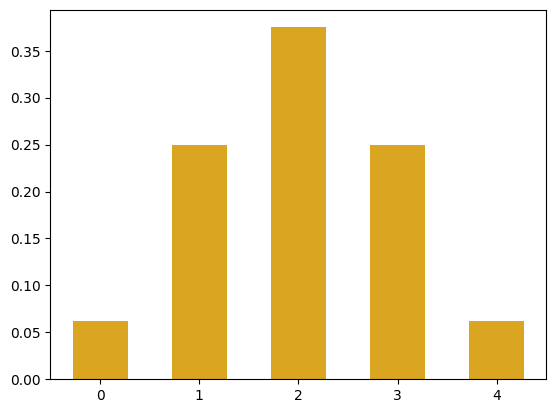

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = np.arange(0, 4 + 1)
prob = [bin.pmf(h) for h in h]

plt.bar(h, prob, width=0.55, color='goldenrod')

🔹 Ejercicio 2: Distribución de Poisson

Un cajero atiende a 5 clientes en un tiempo de 30 minutos. Se pide:

* Calcular la probabilidad de que al menos se atiendan a 3 clientes en 15 minutos
* Calcular la probabilidad de atender como máximo 6 clientes en 10 minutos.
* Generar el gráfico de la distribución de probabilidad con una media de 30 minutos, y luego comparar con media de 10 y 20 minutos.


Se importa la libreria y se observa la prob que atienda a 5 clientes en 30 min.

In [ ]:
from scipy.stats import poisson
media_30_min = 5
poi30 = poisson(media_30_min)
poi30.cdf(5)

np.float64(0.615960654833063)

In [ ]:
poi15 = poisson(media_30_min/2)
print('Al menos 3 clientes en 15 min:',(1 - poi15.cdf(3)))

Al menos 3 clientes en 15 min: 0.24242386686693385


In [ ]:
poi10 = poisson(media_30_min/3)
print('Maximo 6 clientes en 10 min:',poi10.cdf(6))

Maximo 6 clientes en 10 min: 0.998320624390836


Grafico de mu 5 clientes en 30 min

<BarContainer object of 16 artists>

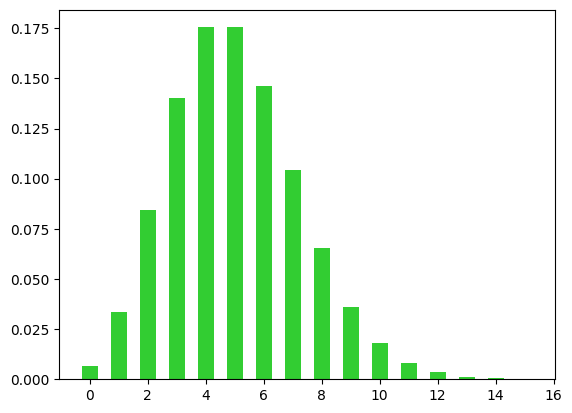

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange (0, 15 +1)
y30 = [poi30.pmf(x) for x in x]

plt.bar(x, y30, width=0.55, color='limegreen')

Grafico de mu de 3.333 (10/3) clientes en 20 min

<BarContainer object of 16 artists>

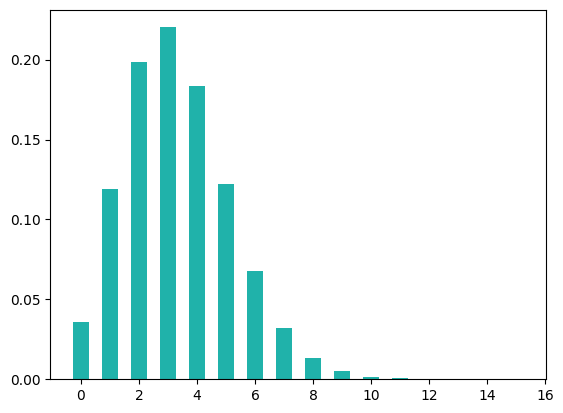

In [ ]:
poi20 = poisson(media_30_min*(2/3))

y20 = [poi20.pmf(x) for x in x]
plt.bar(x, y20, width = 0.55, color = 'lightseagreen')

Grafico de mu 1.666 (5/3) clientes en 10 min

<BarContainer object of 16 artists>

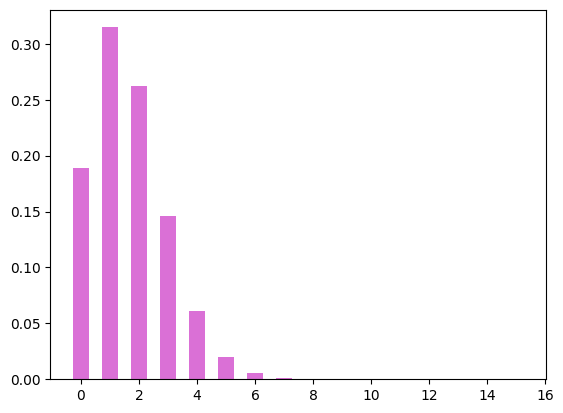

In [ ]:
y10 = [poi10.pmf(x) for x in x]
plt.bar(x, y10, width = 0.55, color = 'orchid')

🔹 Ejercicio 3: Distribución Uniforme

El tiempo de espera por el autobus tiene una distribución uniforme entre 10 y 15 minutos. Se pide:

* Generar el gráfico de la distribución
* Calcular la media
* Calcular la probabilidad de que la espera sea mayor a 12 minutos
* Calcular la probabilidad de que la espera esté entre 11 y 13 minutos


Aplicamos la formula de la distribucion uniforme para generar las alturas en y.

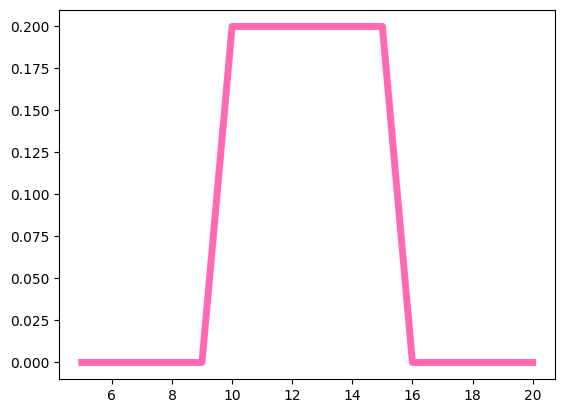

In [2]:
from scipy.stats import uniform
import numpy as np
import matplotlib.pyplot as plt
a = 10
b = 15

uni = uniform(a, b - a)
x = np.arange (5, 20 + 1)
y = [1/(b - a) if a <= x <= b else 0 for x in x]
plt.plot(x, y, linewidth = 5, color = 'hotpink')

In [3]:
print('La media es:', uni.mean())
print('Probabilidad de espera mayor a 12 minutos:', 1 - uni.cdf(12))
print('Entre 11 y 13 minutos:', uni.cdf(13) - uni.cdf(11))

La media es: 12.5
Probabilidad de espera mayor a 12 minutos: 0.6
Entre 11 y 13 minutos: 0.39999999999999997


🔹 Ejercicio 4: Distribución Exponencial

El tiempo de atención en una estación de servicio tiene una media de 5 minutos. Se pide:

* Generar el gráfico de la distribución exponencial para este caso.
* Calcular la probabilidad de que como máximo el tiempo de atención sea 3 minutos.
* Calcular la probabilidad de que el tiempo de atención sea mayor a 1 minutos.


Usamos la formula de la exponencial para generar la grafica.

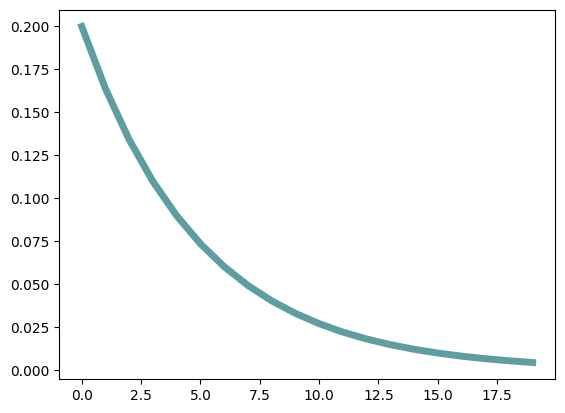

In [4]:
from scipy.stats import expon
lam = 1 / 5
exp = expon(lam)
x = np.arange(0 , 20)
y = lam * np.exp(-lam * x)
plt.plot(x, y, linewidth = 5, color = 'cadetblue')

In [5]:
print('Prob. Maximo tiempo de atencion es 3 minutos:', exp.cdf(3))
print('Prob. tiempo de atencion es mayor a 1 minuto:', 1 - exp.cdf(1))

Prob. Maximo tiempo de atencion es 3 minutos: 0.9391899373747821
Prob. tiempo de atencion es mayor a 1 minuto: 0.44932896411722156


🔹 Ejercicio 5: Distribución Normal

Generar aleatoriamente las calificaciones de 100 estudiantes entre 20 y 100 puntos.

* Hallar la media y la desviación estándar

* Hallar los cuartiles 1, 2 y 3
* Generar un boxplot
* Asumiendo que la distribución es normal, calcular la probabilidad de que una calificación seleccionada al azar esté entre 51 y 70.


Generamos las calificiones

In [6]:
calificaciones = np.random.randint(20, 100 + 1 , 100)
calificaciones.sort()

mu = np.mean(calificaciones)
sigma = np.var(calificaciones) ** (1/2)
print('La media es mu:', mu, 'La desviacion estandar sigma:', sigma)
print('Cuartil 1:', np.quantile(calificaciones,[0.25]))
print('Cuartil 2:', np.quantile(calificaciones,[0.5]))
print('Cuartil 3:', np.quantile(calificaciones,[0.75]))

La media es mu: 62.66 La desviacion estandar sigma: 24.840378419017693
Cuartil 1: [43.]
Cuartil 2: [62.5]
Cuartil 3: [88.]


{'whiskers': [<matplotlib.lines.Line2D at 0x7ffa154dd850>,
 'caps': [<matplotlib.lines.Line2D at 0x7ffa154dde80>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ffa154dd580>],
 'medians': [<matplotlib.lines.Line2D at 0x7ffa154de4b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ffa154ded20>],
 'means': []}

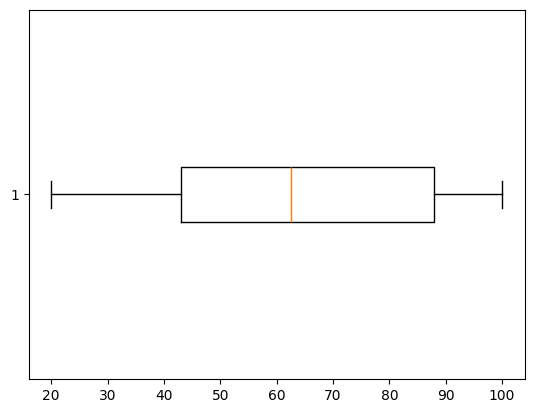

In [9]:
plt.boxplot(calificaciones, vert = False)

In [11]:
from scipy.stats import norm
nr = norm()
z1 = (51 - mu)/sigma
z2 = (70 - mu)/sigma
print('Asumiendo distribución es normal, probabilidad de la calificación entre 51 y 70 es:', nr.cdf(z2) - nr.cdf(z1))

Asumiendo distribución es normal, probabilidad de la calificación entre 51 y 70 es: 0.296795988986642


###Parte 2: Regresión Lineal (Sklearn)
🔹 Ejercicio 6: Regresión Lineal

* Con base en los aspectos desarrollados en clase para la regresión lineal simple, investigar las características de la regresión lineal multivariable.
* Por medio de sklearn, realizar el ajuste de una regresión lineal para el siguiente dataset: http://hubia.bo/my_resources/experiment.csv donde PE es la variable dependiente, y AT, V, AP y RH son las variables independientes.
* Evaluar el R2 score de la regresión lineal.


Importamos las librerias y leemos los datos

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('experiment.csv')
df.head(10)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
5,13.97,39.16,1016.05,84.60,470.96
6,22.10,71.29,1008.20,75.38,442.35
7,14.47,41.76,1021.98,78.41,464.00
8,31.25,69.51,1010.25,36.83,428.77
9,6.77,38.18,1017.80,81.13,484.31


Dividimos los datos y entrenamos el modelo

In [20]:
x, y = df.iloc[:,0: 3+1], df.iloc[:,4]
multilr = LinearRegression()
multilr.fit(x, y)

LinearRegression()

Realizamos:
* Una prediccion suelta
* La prediccion de todos los elementos
* El error media al cuadrado
* El valor r2

In [27]:
print('Prediccion:', multilr.predict([[23,40,1055,31]]))
y_pred = multilr.predict(x)
print('Error media cuadrado:', mean_squared_error(y, y_pred))
print('Valor r2:',r2_score(y, y_pred))

Prediccion: [460.36764446]
Error media cuadrado: 20.767397532535014
Valor r2: 0.9286960898122537


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
